2026-02-08 17:12:47.510502: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-08 17:12:47.511832: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-08 17:12:47.538414: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-08 17:12:47.538963: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-08 17:12:48.067711: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

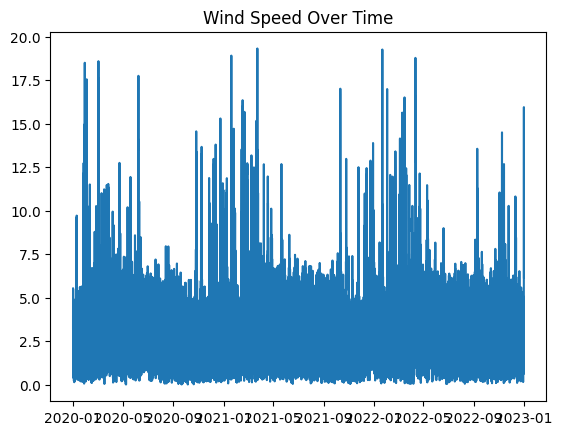

Rolling signature shape: (18388, 19, 12)
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 19, 12)]             0         []                            
                                                                                                  
 conv1d (Conv1D)             (None, 19, 16)               592       ['input_1[0][0]']             
                                                                                                  
 dropout (Dropout)           (None, 19, 16)               0         ['conv1d[0][0]']              
                                                                                                  
 conv1d_1 (Conv1D)           (None, 19, 16)               784       ['dropout[0][0]']             
                                                     

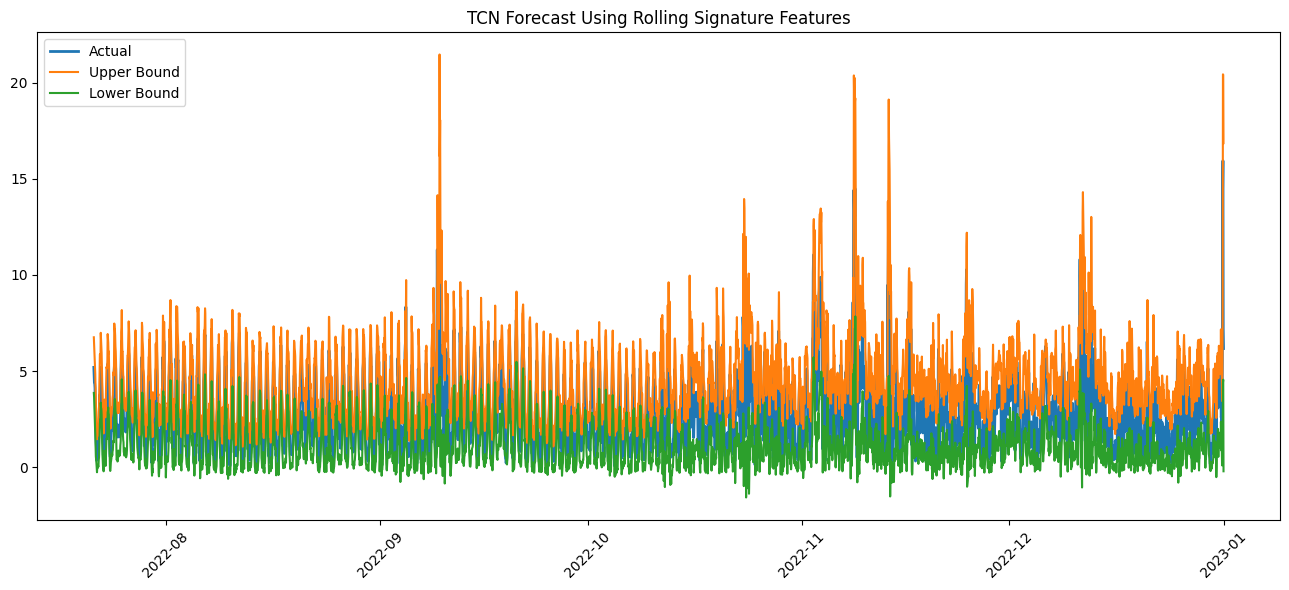

In [1]:
# ==========================================================
# FULL PIPELINE: LeadLag → Rolling Signatures → TCN (Tube Loss)
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import signatory
from torch import nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, TransformerMixin
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Conv1D, Dropout, Add, Dense
from tensorflow.keras.layers import MaxPooling1D, Flatten
from tensorflow.keras.models import Model
import os
import csv
from datetime import datetime

# ---------------------------
# 0. Reproducibility
# ---------------------------
SEED = 48
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

device = "cuda" if torch.cuda.is_available() else "cpu"


# ---------------------------
# 1. LOAD DATA
# ---------------------------
df = pd.read_csv(
    "/mnt/alpha/Research/Signature_based_UQ/dataset/los angeles.csv",
    index_col="Date/Time",
    parse_dates=True
)
df = df[df.index.minute == 0]
df = pd.DataFrame({"wind": df["120m"]}, index=df.index)

plt.plot(df)
plt.title("Wind Speed Over Time")
plt.show()


# ---------------------------
# 2. CONFIDENCE / TUBE LOSS
# ---------------------------
r = 0.50
q = 0.95
delta = 0.0001

PICP_TARGET = 0.95

def confidence_loss(y_true, y_pred):
    y_true = y_true[:, 0]
    f1, f2 = y_pred[:, 0], y_pred[:, 1]

    c1 = (1 - q) * (y_true - f2)
    c2 = (1 - q) * (f1 - y_true)
    c3 = q * (f2 - y_true)
    c4 = q * (y_true - f1)

    cond1 = tf.logical_and(y_true <= f1, y_true >= f2)
    cond2 = y_true > (r * f1 + (1 - r) * f2)
    cond3 = f2 > y_true

    loss = tf.where(cond1,
                    tf.where(cond2, c1, c2),
                    tf.where(cond3, c3, c4))
    return loss + delta * tf.abs(f1 - f2)


# ---------------------------
# 3. WINDOWING
# ---------------------------
input_window = 24
val_frac = 0.15
test_frac = 0.15

split_val = int(len(df) * (1 - val_frac - test_frac))
split_test = int(len(df) * (1 - test_frac))

train = df[:split_val]
val   = df[split_val:split_test]
test  = df[split_test:]


def make_windows(arr, win):
    X, Y = [], []
    for i in range(len(arr) - win):
        X.append(arr[i:i+win])
        Y.append(arr[i+win])
    return np.array(X), np.array(Y)


train_x, train_y = make_windows(train.values, input_window)
val_x,   val_y   = make_windows(val.values,   input_window)
test_x,  test_y  = make_windows(test.values,  input_window)

train_y = train_y.reshape(-1, 1)
val_y   = val_y.reshape(-1, 1)
test_y  = test_y.reshape(-1, 1)


# ---------------------------
# 4. NORMALIZATION
# ---------------------------
scaler_x = MinMaxScaler().fit(train_x.reshape(-1, 1))
scaler_y = MinMaxScaler().fit(train_y)

train_x = scaler_x.transform(train_x.reshape(-1, 1)).reshape(train_x.shape)
val_x   = scaler_x.transform(val_x.reshape(-1, 1)).reshape(val_x.shape)
test_x  = scaler_x.transform(test_x.reshape(-1, 1)).reshape(test_x.shape)

train_y_s = scaler_y.transform(train_y)
val_y_s   = scaler_y.transform(val_y)
test_y_s  = scaler_y.transform(test_y)


# ---------------------------
# 5. LEAD–LAG + SIGNATURE
# ---------------------------
class LeadLagTransform:
    def __call__(self, x):
        B, T, _ = x.shape
        x = x.repeat_interleave(2, dim=1)
        lead = x[:, 1:, :]
        lag  = x[:, :-1, :]
        return torch.cat([lead, lag], dim=2)


class SignatureExtractor(nn.Module):
    def __init__(self, depth):
        super().__init__()
        self.signature = signatory.Signature(depth=depth)
        self.leadlag = LeadLagTransform()

    def forward(self, x):
        x_ll = self.leadlag(x)          # (B, 2T-1, 2)
        B, T, _ = x_ll.shape
        t = torch.linspace(0, 1, T, device=x.device)
        t = t.view(1, T, 1).repeat(B, 1, 1)
        x_aug = torch.cat([x_ll, t], dim=2)
        return self.signature(x_aug, basepoint=True)


sig_depth = 2
sig_extractor = SignatureExtractor(sig_depth).to(device).eval()


# ---------------------------
# 6. ROLLING SIGNATURE FEATURES
# ---------------------------
subwindow = 6
stride = 1

def extract_rolling_signatures(X):
    all_feats = []
    with torch.no_grad():
        for i in range(len(X)):
            feats = []
            for t in range(0, X.shape[1] - subwindow + 1, stride):
                sub = torch.tensor(
                    X[i:i+1, t:t+subwindow],
                    dtype=torch.float32,
                    device=device
                )
                sig = sig_extractor(sub)
                feats.append(sig.cpu().numpy()[0])
            all_feats.append(np.stack(feats, axis=0))
    return np.array(all_feats)


trainF = extract_rolling_signatures(train_x)
valF   = extract_rolling_signatures(val_x)
testF  = extract_rolling_signatures(test_x)

print("Rolling signature shape:", trainF.shape)  # (N, K, D)


# ---------------------------
# 7. TCN MODEL
# ---------------------------
# def tcn_block(x, f, k, d, drop):
#     skip = x
#     x = Conv1D(f, k, padding="causal", dilation_rate=d, activation="relu")(x)
#     x = Dropout(drop)(x)
#     x = Conv1D(f, k, padding="causal", dilation_rate=d, activation="relu")(x)
#     x = Dropout(drop)(x)
#     if skip.shape[-1] != f:
#         skip = Conv1D(f, 1, padding="same")(skip)
#     return Add()([x, skip])


# def create_tcn(input_shape, filters=[32, 32, 32], k=3, drop=0.01):
#     inp = Input(input_shape)
#     x = inp
#     for i, f in enumerate(filters):
#         x = tcn_block(x, f, k, 2**i, drop)
#     x = Dense(32, activation="relu")(x[:, -1, :])
#     out = Dense(2)(x)
#     return Model(inp, out)

def tcn_block(x, f, k, d, drop):
    skip = x
    x = Conv1D(f, k, padding="causal", dilation_rate=d, activation="relu")(x)
    x = Dropout(drop)(x)
    x = Conv1D(f, k, padding="causal", dilation_rate=d, activation="relu")(x)
    x = Dropout(drop)(x)
    if skip.shape[-1] != f:
        skip = Conv1D(f, 1, padding="same")(skip)
    return Add()([x, skip])


def create_tcn(input_shape, filters=[16], k=3, drop=0.1):
    inp = Input(input_shape)
    x = inp
    for i, f in enumerate(filters):
        x = tcn_block(x, f, k, 2**i, drop)
    #x = Dense(16, activation="relu")(x[:, -1, :])
    x = Flatten()(x)
    out = Dense(2)(x)
    return Model(inp, out)


tcn = create_tcn((trainF.shape[1], trainF.shape[2]))
tcn.compile(loss=confidence_loss, optimizer=Adam(0.001))
print(tcn.summary())


# ---------------------------
# 8. TRAIN
# ---------------------------
tcn.fit(
    trainF, train_y_s,
    validation_data=(valF, val_y_s),
    epochs=250,
    batch_size=64,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=1
)


# ---------------------------
# 9. PREDICT + METRICS
# ---------------------------
pred = tcn.predict(testF, verbose=0)

y_u = scaler_y.inverse_transform(pred[:, 0].reshape(-1, 1)).ravel()
y_l = scaler_y.inverse_transform(pred[:, 1].reshape(-1, 1)).ravel()
y_true = scaler_y.inverse_transform(test_y_s).ravel()

# PICP = np.mean((y_u > y_true) & (y_l < y_true))
# MPIW = np.mean(y_u - y_l)

# ==========================================================
# 12B. CWC EVALUATION (LUBE METRIC)
# ==========================================================

def compute_cwc(y_true, y_l, y_u,
                mu=0.95,
                gamma=1.0,
                eta=50.0,
                normalize=True):
    """
    Coverage Width-Based Criterion (CWC)

    Parameters
    ----------
    y_true : array
        True targets
    y_l : array
        Lower prediction bounds
    y_u : array
        Upper prediction bounds
    mu : float
        Nominal coverage level (e.g. 0.95)
    gamma : float
        Penalty activation coefficient
    eta : float
        Penalty sharpness
    normalize : bool
        Whether to normalize MPIW

    Returns
    -------
    cwc : float
    picp : float
    mpiw : float
    nmpiw : float
    """

    # Coverage
    picp = np.mean((y_true >= y_l) & (y_true <= y_u))

    # Width
    mpiw = np.mean(y_u - y_l)

    if normalize:
        y_range = np.max(y_true) - np.min(y_true)
        nmpiw = mpiw / y_range
    else:
        nmpiw = mpiw

    # CWC penalty
    if picp >= mu:
        cwc = nmpiw
    else:
        cwc = nmpiw * (1 + gamma * np.exp(-eta * (picp - mu)))

    return cwc, picp, mpiw, nmpiw


def append_results_to_csv(
    csv_path,
    dataset,
    delta,
    sig_depth,
    tcn_filters,
    dropout,
    train_metrics,
    val_metrics,
    test_metrics
):
    """
    Appends experiment results to a CSV file.
    """

    # Ensure directory exists
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)

    header = [
        "timestamp",
        "dataset",
        "delta",
        "sig_depth",
        "tcn_filters",
        "dropout",
        "split",
        "CWC",
        "PICP",
        "MPIW",
        "NMPIW",
    ]

    rows = []
    timestamp = datetime.now().isoformat(timespec="seconds")

    for split_name, metrics in zip(
        ["train", "val", "test"],
        [train_metrics, val_metrics, test_metrics]
    ):
        CWC, PICP, MPIW, NMPIW = metrics
        rows.append([
            timestamp,
            dataset,
            delta,
            sig_depth,
            str(tcn_filters),
            dropout,
            split_name,
            CWC,
            PICP,
            MPIW,
            NMPIW
        ])

    file_exists = os.path.isfile(csv_path)

    with open(csv_path, mode="a", newline="") as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(header)
        writer.writerows(rows)




# -------------------------------
# Compute CWC on TEST set
# -------------------------------
CWC_test, PICP_test, MPIW_test, NMPIW_test = compute_cwc(
    y_true=y_true,
    y_l=y_l,
    y_u=y_u,
    mu=PICP_TARGET,
    gamma=1.0,
    eta=50.0,
    normalize=True
)



dataset_name = "Los_Angeles_Wind_120m"

results_csv = "/mnt/alpha/Research/Signature_based_UQ/results/tcn_signature_results.csv"

# append_results_to_csv(
#     csv_path=results_csv,
#     dataset=dataset_name,
#     delta=delta,
#     sig_depth=sig_depth,
#     tcn_filters=[16],
#     dropout=0.1,
#     train_metrics=(CWC_train, PICP_train, MPIW_train, NMPIW_train),
#     val_metrics=(CWC_val, PICP_val, MPIW_val, NMPIW_val),
#     test_metrics=(CWC_test, PICP_test, MPIW_test, NMPIW_test),
# )




print("\n===== CWC EVALUATION (TEST) =====")
print(f"PICP   = {PICP_test:.6f}")
print(f"MPIW   = {MPIW_test:.6f}")
print(f"NMPIW  = {NMPIW_test:.6f}")
print(f"CWC    = {CWC_test:.6f}")



# ---------------------------
# 10. PLOT
# ---------------------------
idx = test.index[input_window:input_window + len(y_true)]

plt.figure(figsize=(13, 6))
plt.plot(idx, y_true, label="Actual", linewidth=2)
plt.plot(idx, y_u, label="Upper Bound")
plt.plot(idx, y_l, label="Lower Bound")
plt.title("TCN Forecast Using Rolling Signature Features")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
